In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from google.colab import files

In [ ]:
df_origin = pd.read_csv('/content/drive/MyDrive/Notebooks/DB/K_means/pengu.csv')
df_origin.shape

(344, 7)

## Analisis de la Data Base

Iniciamos revisando que no tengamos valores nulos y que todos los datos sean del mismo tipo.

In [ ]:
display(df_origin)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [ ]:
for c in df_origin.columns:
    null_count = np.sum(pd.isnull(df_origin[c]))  # Contar valores nulos
    data_types = df_origin[c].dropna().apply(type).unique()  # Obtener tipos de datos únicos sin NaN
    print(f'Column: {c} - Nulls: {null_count} - Data Types: {data_types}')

Column: species - Nulls: 0 - Data Types: [<class 'str'>]
Column: island - Nulls: 0 - Data Types: [<class 'str'>]
Column: culmen_length_mm - Nulls: 2 - Data Types: [<class 'float'>]
Column: culmen_depth_mm - Nulls: 2 - Data Types: [<class 'float'>]
Column: flipper_length_mm - Nulls: 2 - Data Types: [<class 'float'>]
Column: body_mass_g - Nulls: 2 - Data Types: [<class 'float'>]
Column: sex - Nulls: 10 - Data Types: [<class 'str'>]


Ahora obtenemos el resto de informacion que nos puede ser util para conocer nuestros datos.

In [ ]:
df_origin = df_origin.dropna()

In [ ]:
df_origin.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


Eliminamos las columnas con datos categoricos para ver la correlacion de nuestros datos, esto puede darnos una idea para encontrar relaciones entre los datos

In [ ]:
df_info = df_origin.drop(['species','island','sex'], axis=1)
df_info.corr()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


Tomaremos una muestra nuestros datos para poder visualizar mejor la informacion, de tal manera que tomaremos la misma cantidad de especies de cada tipo

In [ ]:
df_b = df_origin.groupby('species').sample(n=40, random_state=42)

In [ ]:
df_b['species'].value_counts()

,count
species,
Adelie,40
Chinstrap,40
Gentoo,40


# Procesamiento

In [ ]:
df_k = df_b[['species','culmen_length_mm',	'culmen_depth_mm',	'flipper_length_mm',	'body_mass_g']]
df_k.head()

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
51,Adelie,40.1,18.9,188.0,4300.0
103,Adelie,37.8,20.0,190.0,4250.0
32,Adelie,39.5,17.8,188.0,3300.0
24,Adelie,38.8,17.2,180.0,3800.0
48,Adelie,36.0,17.9,190.0,3450.0


In [ ]:
train_df_list = []
test_df_list = []

# Agrupa por 'species' y divide cada grupo en 80/20
for label, group in df_k.groupby('species'):
    group = group.sample(frac=1, random_state=42).reset_index(drop=True)  # Mezclamos los registros
    n_train = int(0.8 * len(group)) # Indice para hacer el corte

    train_df_list.append(group.iloc[:n_train]) # Lo asignamos al df correspondiente
    test_df_list.append(group.iloc[n_train:])

# Une todas las muestras
train_df = pd.concat(train_df_list).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat(test_df_list).sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
def zscore(df, columns):
    df_norm = df.copy()
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        df_norm[col] = (df[col] - mean) / std
    return df_norm

In [ ]:
# Distancia euclidiana
def e_distance(p1, p2):
    return sum((a - b)**2 for a, b in zip(p1, p2))**0.5

In [ ]:
def plot_clusters(X, clusters, centroids, iteration):
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'orange']
    plt.figure(figsize=(6, 6))

    for i, cluster in enumerate(clusters):
        if cluster:
            xs = [p[0] for p in cluster]
            ys = [p[1] for p in cluster]
            plt.scatter(xs, ys, c=colors[i % len(colors)], label=f'Cluster {i}', alpha=0.6)

    # Graficar centroides con marcador especial
    for i, c in enumerate(centroids):
        plt.scatter(c[0], c[1], c='black', marker='x', s=100, linewidths=3)

    plt.title(f'Iteración {iteration}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
c_norm = ['culmen_length_mm',	'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_norm = zscore(train_df, c_norm)

In [ ]:
df_norm

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,Gentoo,0.546628,-1.240899,1.231637,0.782625
1,Gentoo,-0.050292,-1.495551,0.937149,0.968825
2,Gentoo,0.792419,-0.680664,0.789904,1.465360
3,Gentoo,0.125273,-1.189969,0.937149,1.092959
4,Chinstrap,2.214495,0.185153,-1.566005,-0.644914
...,...,...,...,...,...
91,Chinstrap,1.161105,0.337945,-0.093561,-0.210446
92,Gentoo,0.564185,-0.731595,2.041481,1.961896
93,Adelie,-1.349472,0.643527,-1.639627,-0.769048
94,Gentoo,0.195499,-1.342760,1.084393,1.217093


In [ ]:
X = df_norm[['culmen_length_mm',	'culmen_depth_mm',	'flipper_length_mm',	'body_mass_g']].values.tolist()

# Parámetros
k = 3  # número de clústeres
max_iter = 100

# Inicio aleatorio de los centroides
random.seed(42)
centroids = random.sample(X, k)

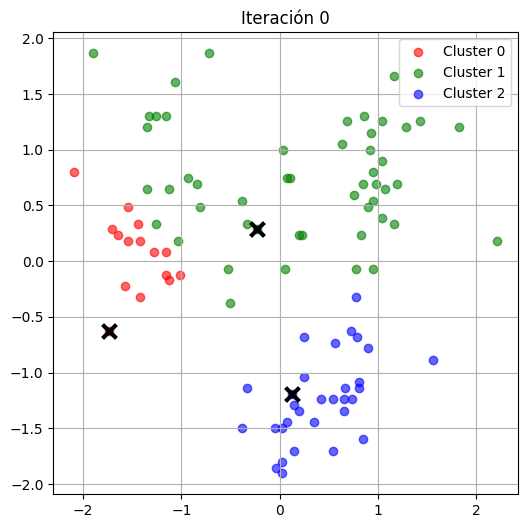

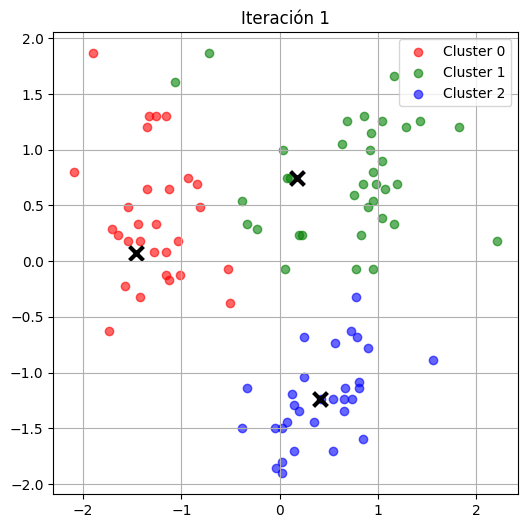

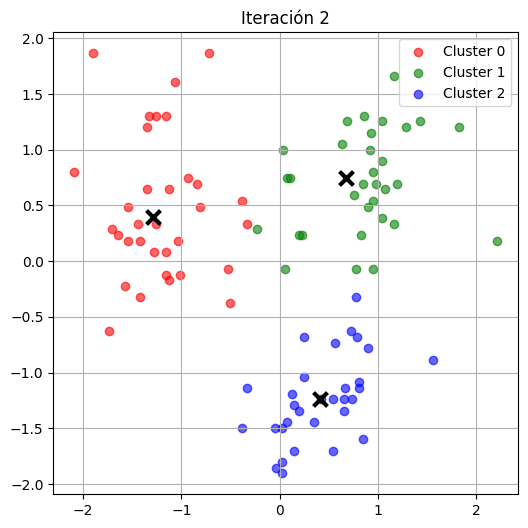

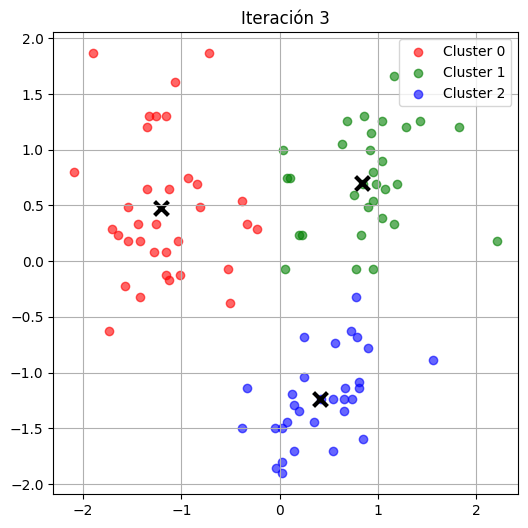

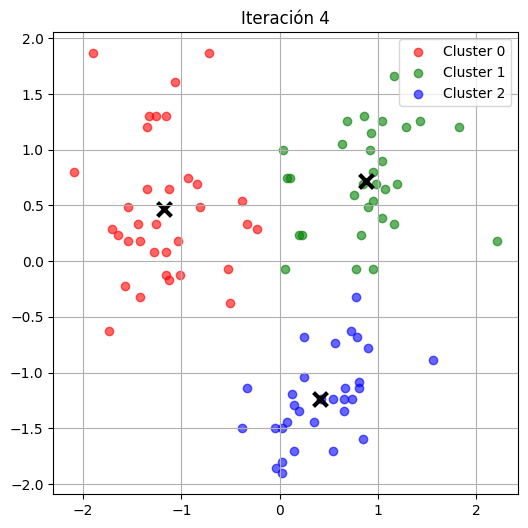

In [ ]:
for iteration in range(max_iter):
    clusters = [[] for _ in range(k)]

    # Asignar puntos a su centroide más cercano
    for point in X:
        distances = [e_distance(point, c) for c in centroids]
        min_index = distances.index(min(distances))
        clusters[min_index].append(point)

    # Graficar las iteraciones
    plot_clusters(X, clusters, centroids, iteration)

    # Guardar los centroides para comparar
    old_centroids = [c[:] for c in centroids]

    # Recalcular centroides
    for i in range(k):
        if clusters[i]:  # Evitar división por cero
            transposed = list(zip(*clusters[i]))
            centroids[i] = [sum(dim) / len(dim) for dim in transposed]

    # Paro si los centroides se mantienen
    if centroids == old_centroids:
        break


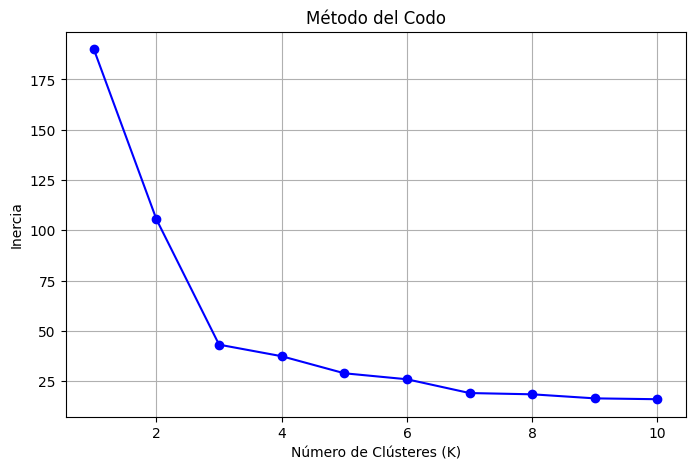

In [ ]:
def calcular_inercia(clusters, centroids):
    total_inertia = 0
    for i, cluster in enumerate(clusters):
        for point in cluster:
            dist = e_distance(point, centroids[i])
            total_inertia += dist**2
    return total_inertia

inertias = []
K_range = range(1, 11)

for k_test in K_range:
    # Inicialización aleatoria de centroides
    random.seed(42)
    centroids = random.sample(X, k_test)

    for _ in range(100):
        clusters = [[] for _ in range(k_test)]
        for point in X:
            distances = [e_distance(point, c) for c in centroids]
            min_index = distances.index(min(distances))
            clusters[min_index].append(point)

        old_centroids = [c[:] for c in centroids]

        # Recalcular centroides
        for i in range(k_test):
            if clusters[i]:
                xs = [p[0] for p in clusters[i]]
                ys = [p[1] for p in clusters[i]]
                centroids[i] = [sum(xs) / len(xs), sum(ys) / len(ys)]

        if centroids == old_centroids:
            break

    # Calcular inercia
    inertia = calcular_inercia(clusters, centroids)
    inertias.append(inertia)

# Graficar método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()


# Error rate

In [ ]:
# Normalizar el df de pruebas con las medias y std del df de entrenamiento
train_means = train_df[c_norm].mean()
train_stds = train_df[c_norm].std()

test_norm = test_df.copy()
for col in c_norm:
    test_norm[col] = (test_norm[col] - train_means[col]) / train_stds[col]

# Asignacion de clusters
X_test = test_norm[c_norm].values.tolist()

def e_distance(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

cluster_assignments = []
for point in X_test:
    distances = [e_distance(point, c) for c in centroids]
    min_index = distances.index(min(distances))
    cluster_assignments.append(min_index)

test_norm['cluster'] = cluster_assignments
test_norm['species'] = test_df['species'].values

# Mapear clusters a etiquetas mayoritarias
cluster_to_label = {}
k = len(centroids)

for i in range(k):
    labels_in_cluster = test_norm[test_norm['cluster'] == i]['species']
    if not labels_in_cluster.empty:
        most_common = labels_in_cluster.value_counts().idxmax()
        cluster_to_label[i] = most_common

# Asignar clasificacion predicha
test_norm['predicted'] = test_norm['cluster'].map(cluster_to_label)

In [ ]:
test_norm['Correcto'] = test_norm['species'] == test_norm['predicted']

total = test_norm.shape[0]
aciertos = test_norm['Correcto'].sum()
porcentaje = 100 * aciertos / total

print(f'Aciertos: {aciertos} de {total} ({porcentaje:.2f}%)')

test_norm

Aciertos: 22 de 24 (91.67%)


,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,cluster,predicted,Prediccion,Correcto
0,Chinstrap,-0.787664,-0.426012,-1.124272,-1.265583,0,Adelie,False,False
1,Gentoo,0.195499,-2.004856,0.569038,0.410223,5,Gentoo,True,True
2,Adelie,-0.506761,1.662136,-0.388050,0.348156,7,Adelie,True,True
3,Gentoo,-0.313639,-1.801134,1.084393,0.844692,5,Gentoo,True,True
4,Chinstrap,1.108436,1.458415,-0.608917,-0.551813,4,Chinstrap,True,True
5,Chinstrap,0.177942,0.592597,-0.903405,-0.955248,6,Chinstrap,True,True
6,Chinstrap,0.248168,-0.476942,-0.977027,-0.706981,2,Chinstrap,True,True
7,Adelie,-1.173907,0.796319,-0.535294,-0.955248,8,Adelie,True,True
8,Gentoo,-0.032736,-1.342760,0.716282,1.217093,9,Gentoo,True,True
9,Adelie,-0.822777,-0.222290,-0.903405,-0.613880,0,Adelie,True,True
